In [25]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


# Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)


In [26]:
df = pd.read_excel("data.xlsx")

print(df.shape)
df.head()


(500, 29)


,id,Gender,Age,Hypertension,Heart Disease,Family History,Heart Procedure,Chest pain,Max Heart Rate,Avg Glusoce level,...,Serum_Creatinine,Serum_Sodium,Insomnia,breath fatigue,Memoryloss,Execise stress,Discoloration,Body Parts,Loss of Appetite,Prediction
0,501,male,52,0,1,Yes,No,4,172,228.69,...,1.9,130,yes,22,yes,no,no,no,yes,Arrhythmia
1,502,male,66,0,1,Yes,Yes,3,156,202.21,...,1.4,140,no,21,yes,yes,no,no,yes,Heart failure
2,503,female,49,1,0,Yes,Yes,2,98,221.90,...,1.3,129,yes,30,yes,yes,no,no,no,CAD
3,504,male,62,1,1,Yes,no,0,108,120.40,...,1.9,137,no,11,no,yes,no,no,no,Normal
4,505,female,38,1,0,Yes,Yes,3,122,174.12,...,2.7,116,no,23,no,yes,yes,skin,no,Congenital


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   500 non-null    int64  
 1   Gender               500 non-null    object 
 2   Age                  500 non-null    int64  
 3   Hypertension         500 non-null    int64  
 4   Heart Disease        500 non-null    int64  
 5   Family History       500 non-null    object 
 6   Heart Procedure      500 non-null    object 
 7   Chest pain           500 non-null    int64  
 8   Max Heart Rate       500 non-null    int64  
 9   Avg Glusoce level    500 non-null    float64
 10  Smoking Status       500 non-null    object 
 11  Cholesterol          500 non-null    int64  
 12  Swelling             376 non-null    object 
 13  Shivering/dizziness  500 non-null    object 
 14  Palpitation          499 non-null    object 
 15  Pain                 500 non-null    obj

In [28]:
df["Prediction"].value_counts()


Prediction
Unknown           79
Normal            73
Arrhythmia        68
CAD               64
Heart failure     57
Cardiomiopathy    55
Congenital        34
heart Failure     25
NORMAL            24
normal            21
Name: count, dtype: int64

In [29]:
df["Prediction"] = df["Prediction"].str.strip().str.lower()

label_mapping = {
    "normal": "Normal",
    "heart failure": "Heart Failure",
    "arrhythmia": "Arrhythmia",
    "cad": "CAD",
    "cardiomiopathy": "Cardiomiopathy",
    "congenital": "Congenital",
    "unknown": "Unknown"
}

df["Prediction"] = df["Prediction"].map(label_mapping)


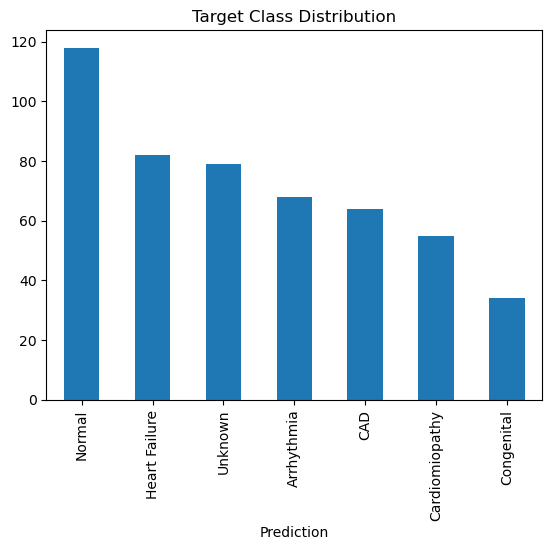

In [30]:
df["Prediction"].value_counts().plot(kind="bar")
plt.title("Target Class Distribution")
plt.show()


In [31]:
target_col = "Prediction"

X = df.drop(columns=[target_col])
y = df[target_col]


In [32]:


df = df.drop(columns=[
    "id",          # non-informative identifier
    "Swelling",    # high missing values
    "Body Parts"   # duplicate of Body Part
])

# Fix column name typo (safe)
df = df.rename(columns={" breath fatigue": "breath fatigue"})


In [33]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical Columns:", len(categorical_cols))
print("Numerical Columns:", len(numerical_cols))


Categorical Columns: 17
Numerical Columns: 11


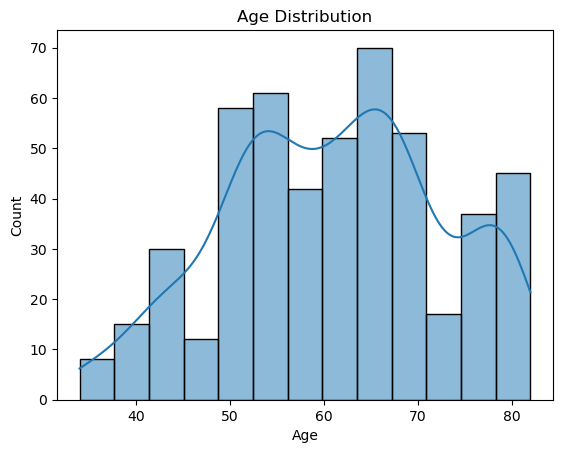

In [34]:
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()


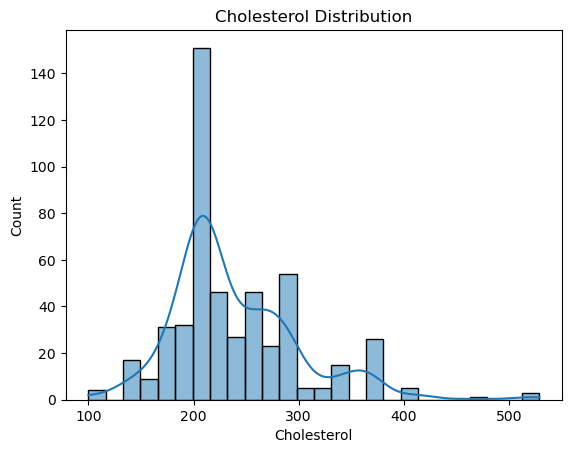

In [35]:
sns.histplot(df["Cholesterol"], kde=True)
plt.title("Cholesterol Distribution")
plt.show()


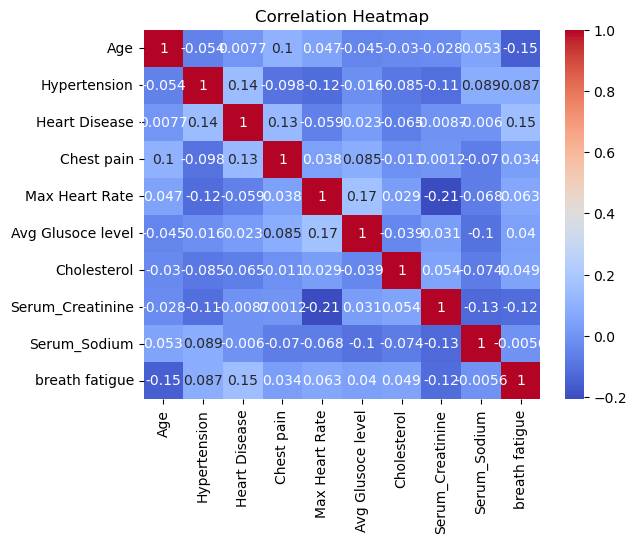

In [36]:
corr = df.select_dtypes(include=["int64", "float64"]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [37]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [39]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
    "Logistic Regression": LogisticRegression(
    max_iter=1000,
    solver="lbfgs"
)

}


In [40]:
results = {}
trained_models = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "report": classification_report(y_test, y_pred, output_dict=True)
    }
    
    trained_models[name] = pipe
    
    print(f"\n{name} Accuracy:", results[name]["accuracy"])



Random Forest Accuracy: 0.78

Gradient Boosting Accuracy: 0.75

Logistic Regression Accuracy: 0.51


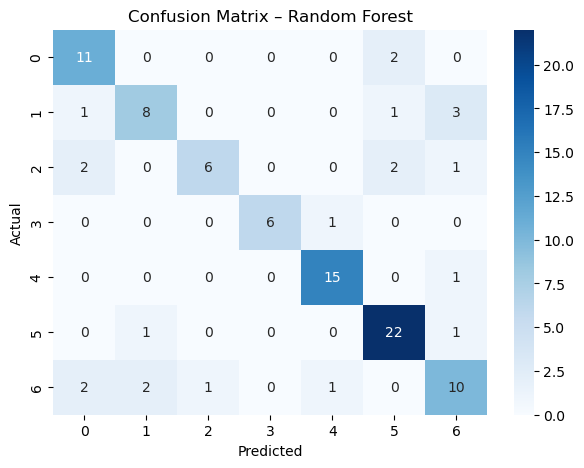

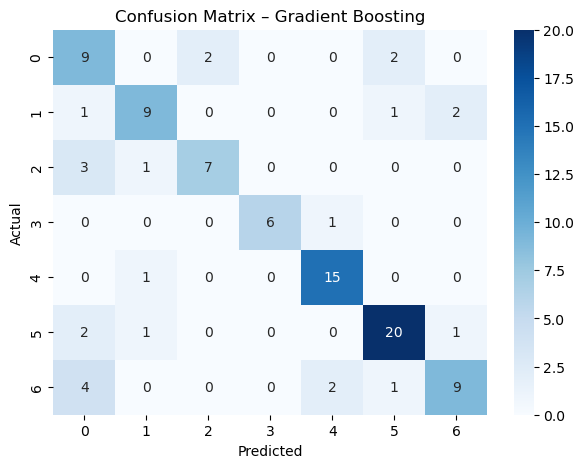

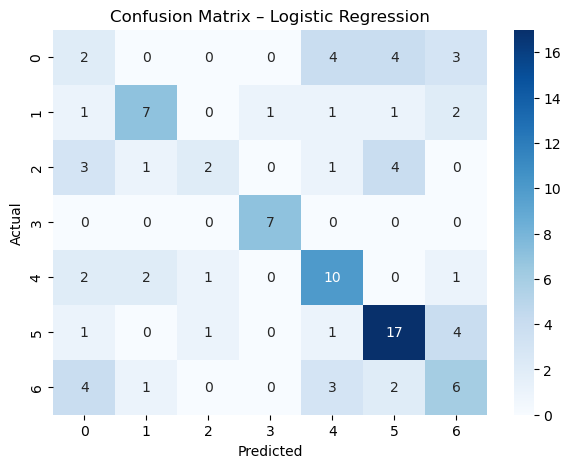

In [41]:
def plot_confusion(model, name):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(7,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

for name, model in trained_models.items():
    plot_confusion(model, name)


In [42]:
classes = y.unique()
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]


In [43]:
def plot_multiclass_roc(model, name):
    y_score = model.predict_proba(X_test)
    
    plt.figure(figsize=(7,6))
    
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {roc_auc:.2f})")
    
    plt.plot([0,1], [0,1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {name}")
    plt.legend()
    plt.show()


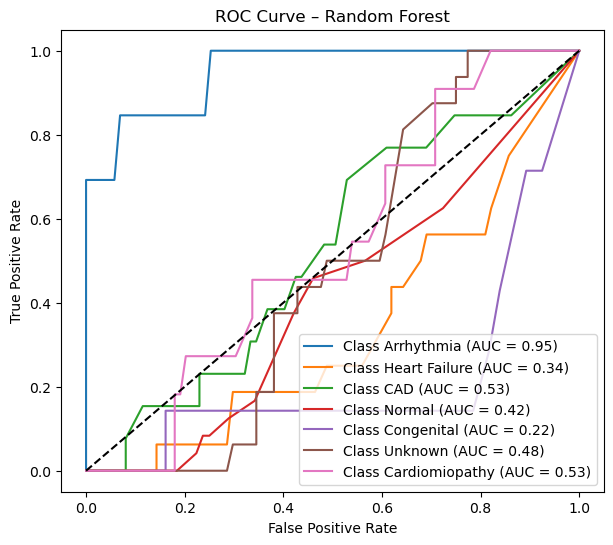

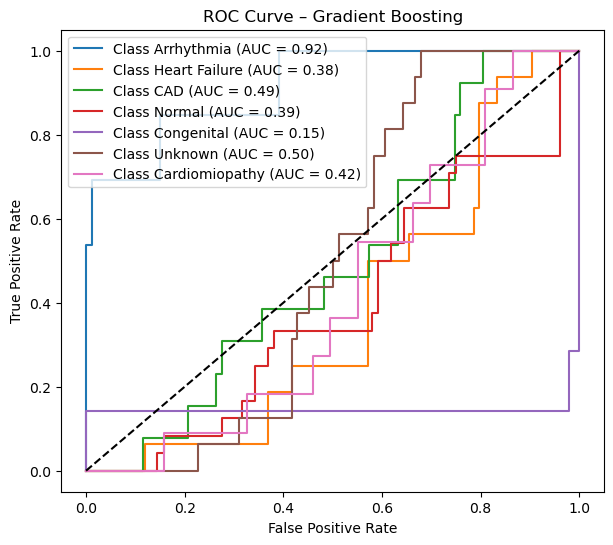

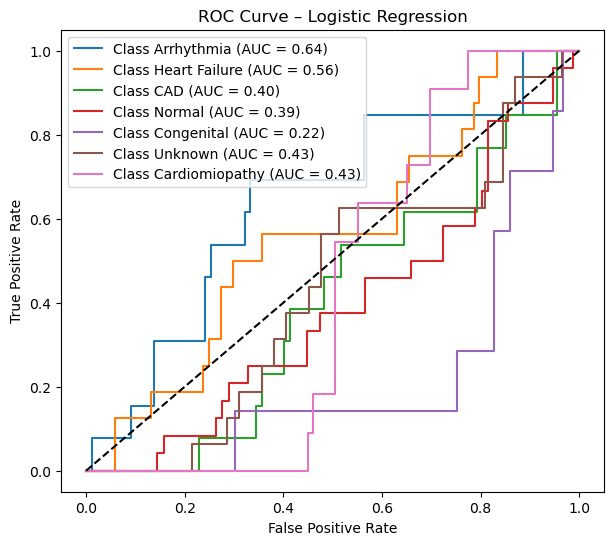

In [44]:
for name, model in trained_models.items():
    plot_multiclass_roc(model, name)


In [45]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Select the best-performing model (Random Forest)
best_model = trained_models["Random Forest"]

# Save the entire pipeline (preprocessing + model)
joblib.dump(best_model, "../models/model.pkl")

print("✅ Final model pipeline saved successfully at ../models/model.pkl")


✅ Final model pipeline saved successfully at ../models/model.pkl
